In [1]:
#Library
import numpy as np
import pandas as pd
import time as tm
# to integrate
from scipy import interpolate
import scipy.integrate as integrate
import matplotlib.pyplot as plt

---

## 2D general code for Poisson's equation

An unstructured triangular **mesh** sets the discretization of a domain. The code generates the mesh using **SciPy’s Delaunay package**. 

Using the Delaunay triangulation algorithm, the SciPy Delaunay class triangulates a given set of points into a mesh object. The mesh object has a few important properties: points, simplices, and convex hull. The points property is a list of all points with x and y coordinates. A simplex contains a list of three points indices that form the triangle. The convex hull is a list of edges, where an edge is a list with the indices of two points. The Delaunay mesh is warped into the Mesh class, which also includes the boundary conditions.

The generic **TriangularElement** class contains the derivative for the shape functions in the triangular element and the transformation between local and global coordinates. The **GaussianQuadrature** class calculates the numerical integration of a triangular element.

The main class **FEPoisson2D** is initialized with the mesh and the right-hand side function f. The algorithm follows the same scheme as described in the article. First, the A and b entries are calculated. The function set_A_b iterates over the elements (simplices) and calculates the local 3 by 3 matrix A and the vector b. The Jacobian is a property of the transformed triangular element. The solution is added to the global matrix based on the original indices.

The Dirichlet boundary condition is applied by multiplying a temporary vector u with the matrix A and subtracting it from b. The temporary vector u has the boundary values at the boundary point indices and is otherwise zero. Therefore, only the necessary multiplications for setting the Dirichlet boundary condition are non-zero. The Neumann boundary condition applies to the domain edges. The information about the edge is stored in the Delaunay object in the convex_hull property. The gradient values of each node are used to calculate the line integral between the points of each edge, and the result is stored in the corresponding index in vector b.

Finally, the equation is being solved for u. The u values where the Dirichlet boundary condition applies are known and should, therefore, be omitted from the calculation. The code below provides a framework for solving a two-dimensional Poisson equation.

see: [link FEM](https://medium.com/@ariel.yaniv/finite-element-method-explained-how-to-solve-the-2d-poisson-equation-part-ii-7179a4871b98)


In [2]:
import numpy as np
from scipy.spatial import Delaunay


class Mesh:
    def __init__(self, x_min, x_max, n_x, y_min, y_max, y_n):
        # Create a list with points coordinate (x,y)
        points = []
        nodes_x = np.linspace(x_min, x_max, n_x)
        nodes_y = np.linspace(y_min, y_max, y_n)
        for nx in nodes_x:
            for ny in nodes_y:
                points.append([nx, ny])
        points = np.array(points)

        # Create Delaunay object
        self.tri = Delaunay(points)

        # Indentify the boundary points
        self.boundary_points = np.unique(self.tri.convex_hull.flatten())

        # Initialize the boundary conditions dictionary
        self.bc_points = {
            "dirichlet": dict(),
            "neumann_edge": dict()
        }


class GenericTriElement:
    def __init__(self):
        # Shape functions derivatives in a local triangular element
        N1_dxi = 1
        N2_dxi = 0
        N3_dxi = -1
        N1_deta = 0
        N2_deta = 1
        N3_deta = -1
        self.dN = np.array([
            [N1_dxi, N1_deta],
            [N2_dxi, N2_deta],
            [N3_dxi, N3_deta]])

    @staticmethod
    def N1(xi, eta):
        return xi

    @staticmethod
    def N2(xi, eta):
        return eta

    @staticmethod
    def N3(xi, eta):
        return 1 - xi - eta

    # Coordinate transformation local to global
    def get_xy(self, xi, eta, p1, p2, p3):
        return (p1[0] * self.N1(xi, eta) + p2[0] * self.N2(xi, eta) + p3[0] * self.N3(xi, eta),
                p1[1] * self.N1(xi, eta) + p2[1] * self.N2(xi, eta) + p3[1] * self.N3(xi, eta))


class GaussianQuadratureTri:
    def __init__(self):
        # nip = 3 # number of integration points
        self.wps = [(0.5, 0.5), (0.5, 0), (0, 0.5)]  # weighted points
        self.ws = (1 / 6, 1 / 6, 1 / 6)              # weights
        self.tri_element = GenericTriElement()

    # Calculate the numerical integration for each node
    def calculate(self, _f, p1, p2, p3):
        # Get the global (x,y) coordinates at the weighted points
        xys = [self.tri_element.get_xy(wp[0], wp[1], p1, p2, p3) for wp in self.wps]

        return np.array([
            sum([w * _f(xy[0], xy[1]) * self.tri_element.N1(
                wp[0], wp[1]) for w, wp, xy in zip(self.ws, self.wps, xys)]),
            sum([w * _f(xy[0], xy[1]) * self.tri_element.N2(
                wp[0], wp[1]) for w, wp, xy in zip(self.ws, self.wps, xys)]),
            sum([w * _f(xy[0], xy[1]) * self.tri_element.N3(
                wp[0], wp[1]) for w, wp, xy in zip(self.ws, self.wps, xys)]),
        ])


class FEPoisson2D:
    def __init__(self, _mesh, _f):
        self.gte = GenericTriElement()
        self.gauss_quad = GaussianQuadratureTri()

        self.mesh = _mesh
        self.n_elements = self.mesh.tri.nsimplex
        self.n_points = self.mesh.tri.npoints

        self.f = _f

        self.A = np.zeros((self.n_points, self.n_points))
        self.b = np.zeros((self.n_points, 1))
        self.u = np.zeros_like(self.b)

    # @staticmethod
    def calc_local_update_Ab(self, p1, p2, p3):
        # Calculate the Jacobian, its determinant, and inverse
        j11 = p1[0] - p3[0]  # x_1 - x_3
        j12 = p1[1] - p3[1]  # y_1 - y_3
        j21 = p2[0] - p3[0]  # x_2 - x_3
        j22 = p2[1] - p3[1]  # y_2 - y_3
        j_det = j11 * j22 - j21 * j12
        j_inv = np.array([[j22, -j12],
                          [-j21, j11]]) / j_det

        # Calculate matrix solution of one element
        A_local = np.zeros((3, 3))
        b_local = np.zeros((3, 1))
        for j in range(3):
            A_local[j, j] = 0.5 * np.dot(j_inv, self.gte.dN[j, :]
                                         ) @ np.dot(j_inv, self.gte.dN[j, :]) * j_det
        A_local[1, 0] = A_local[0, 1] = 0.5 * np.dot(
            j_inv, self.gte.dN[1, :]) @ np.dot(j_inv, self.gte.dN[0, :]) * j_det
        A_local[2, 0] = A_local[0, 2] = 0.5 * np.dot(
            j_inv, self.gte.dN[2, :]) @ np.dot(j_inv, self.gte.dN[0, :]) * j_det
        A_local[1, 2] = A_local[2, 1] = 0.5 * np.dot(
            j_inv, self.gte.dN[2, :]) @ np.dot(j_inv,self.gte.dN[1, :]) * j_det
        b_local = j_det * self.gauss_quad.calculate(self.f, p1, p2, p3)

        return A_local, b_local

    def set_A_b(self):
        # Calculate the global matrix solution
        for i, el_ps in enumerate(self.mesh.tri.simplices):
            # Extract element's nodes
            p1, p2, p3 = (self.mesh.tri.points[el_ps[0]],
                          self.mesh.tri.points[el_ps[1]],
                          self.mesh.tri.points[el_ps[2]])

            # Store local element's solution
            A_local, b_local = self.calc_local_update_Ab(p1, p2, p3)

            # Assemble element's matrix solution into global matrix
            columns = np.array([el_ps for _ in range(3)])
            rows = columns.T
            self.A[rows, columns] += A_local
            self.b[el_ps, 0] += b_local

    def set_boundary_conditions(self):
        # Set Dirichlet boundary conditions
        u_temp = np.zeros_like(self.b)
        for key, value in self.mesh.bc_points["dirichlet"].items():
            u_temp[key] = value
        self.b -= self.A @ u_temp

        # Set Neumann boundary conditions
        for ch_idx, du_values in self.mesh.bc_points["neumann_edge"].items():
            # convex_hull is a list with pair of point indices
            ch_points = self.mesh.tri.convex_hull[ch_idx]
            p1, p2 = self.mesh.tri.points[ch_points]
            distance = np.sqrt((p1[0] - p2[0]) ** 2 + (p1[1] - p2[1]) ** 2)
            # Store the line integral in vector b
            for p_idx, du_value in zip(ch_points, du_values):
                self.b[p_idx] += 0.5 * distance * du_value  # du_boundary

    def process(self):
        # Initialize the A and b
        self.A = np.zeros((self.n_points, self.n_points))
        self.b = np.zeros((self.n_points, 1))

        # Calculate A and b entries
        self.set_A_b()

        # Set boundary conditions
        self.set_boundary_conditions()

    def solve(self):
        # Initialize u
        self.u = np.zeros_like(self.b)

        # Exclude known u from the Dirichlet boundary condition
        points_to_solve = []
        for p_idx in range(self.mesh.tri.npoints):
            if p_idx not in self.mesh.bc_points["dirichlet"]:
                points_to_solve.append(p_idx)
        # Solve u = A^-1 * b
        self.u[points_to_solve] = np.dot(np.linalg.inv(self.A[points_to_solve, :][:, points_to_solve]),
                                         self.b[points_to_solve])

        # Set the known
        for key, value in self.mesh.bc_points["dirichlet"].items():
            self.u[key] = value

In [3]:
import matplotlib.pyplot as plt
from matplotlib import cm

if __name__ == '__main__':
    """
    Problem setup
    """
    # Right-hand side function
    def RHS(_x, _y):

        return -2

    # Domain space
    x_min, x_max, n_x = 0, 1, 16
    y_min, y_max, y_n = 0, 1, 25

    """ 
    Create rectangular mesh 
    """
    # Create a mesh object with Delaunay mesh and a 
    #    boundary condition dictionary
    mesh = Mesh(x_min, x_max, n_x, y_min, y_max, y_n)
    # Mesh data
    inner_points = [i for i in range(len(mesh.tri.points))
                    if i not in mesh.boundary_points]
    print("The mesh has {} boundary nodes, and {} internal nodes".format(
        len(mesh.boundary_points), len(inner_points)))

    """ 
    Set boundary conditions 
    """
    # Set the Dirichlet boundary conditions
    u00 = 2
    for point_index in mesh.boundary_points:
        p = mesh.tri.points[point_index]
        if p[0] == 0 and p[1] == 0:
            mesh.bc_points["dirichlet"][point_index] = u00

    # Set the Neumann boundary conditions
    for ch_idx, edge_points in enumerate(mesh.tri.convex_hull):
        p1_idx, p2_idx = edge_points
        p1, p2 = mesh.tri.points[edge_points]
        if p1[0] == 0 and p2[0] == 0:  # x = 0, East
            mesh.bc_points["neumann_edge"][ch_idx] = [0, 0]
        elif p1[0] == 1 and p2[0] == 1:  # x = 1, West
            mesh.bc_points["neumann_edge"][ch_idx] = [1, 1]
        elif p1[1] == 0 and p2[1] == 0:  # y = 0, South
            mesh.bc_points["neumann_edge"][ch_idx] = [0, 0]
        elif p1[1] == 1 and p2[1] == 1:  # y = 1, North
            mesh.bc_points["neumann_edge"][ch_idx] = [1, 1]

    """ 
    Solve the 2D Poisson problem 
    """
    # Set a simulation object
    poisson = FEPoisson2D(mesh, RHS)
    # Process - build A and b
    poisson.process()
    # Solve for u = A^-1 b
    poisson.solve()
    # Get the result
    u = poisson.u


The mesh has 78 boundary nodes, and 322 internal nodes


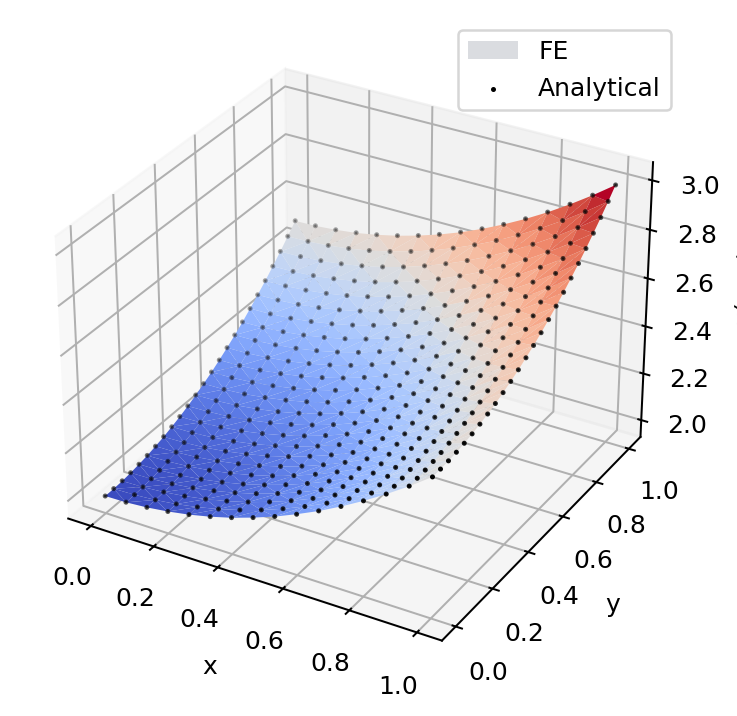

In [4]:
""" 
Plot FE and analytical solution 
"""
# Analytical solution
x = mesh.tri.points[:, 0]
y = mesh.tri.points[:, 1]
u_exact = 0.5 * (x ** 2 + y ** 2) + u00

ax = plt.figure(dpi=180).add_subplot(projection='3d')
ax.plot_trisurf(
    mesh.tri.points[:, 0], mesh.tri.points[:, 1], u.flatten(),
    linewidth=0.2, antialiased=True, cmap=cm.coolwarm, label="FE")
ax.scatter(x, y, u_exact, marker='o', c='black', s=1, label="Analytical")
# Rotate the view: Elevation (z), Azimuth (x,y)
#ax.view_init(elev=30, azim=0) 
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel(r'$u(x,y)$')
ax.legend()
plt.show()